In [2]:
!pip install -q -U watermark

In [3]:
!pip install -q efficient_apriori

In [4]:
import numpy as np
import pandas as pd
import efficient_apriori
import matplotlib.pyplot as plt
from datetime import datetime
from itertools import combinations
from efficient_apriori import apriori
import warnings
warnings.filterwarnings('ignore')

In [5]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



# **Carregando os Dados**

In [6]:
dados_departamentos = pd.read_csv('departamentos.csv')
dados_corredores = pd.read_csv('corredores.csv')
dados_produtos = pd.read_csv('produtos.csv')
dados_pedidos = pd.read_csv('pedidos.csv')
dados_transacoes = pd.read_csv('transacoes.csv')

In [7]:
import pandas as pd
dados_transacoes = pd.read_csv('transacoes.csv', nrows=500000)

## **Análise Exploratória**

### **Detalhes do Tamanho de cada Dataset via Programação**

In [8]:
# Total de registros por dataset
conta_arrays = np.array([['dados_departamentos', len(dados_departamentos)],
                         ['dados_corredores', len(dados_corredores)],
                         ['dados_produtos', len(dados_produtos)],
                         ['dados_pedidos', len(dados_pedidos)],
                         ['dados_transacoes', len(dados_transacoes)]])

In [9]:
# converte o array em dataframe
contagem = pd.DataFrame(data=conta_arrays, columns=['Arquivo', 'Total de Registros'])

In [10]:
print(contagem)

               Arquivo Total de Registros
0  dados_departamentos                 21
1     dados_corredores                134
2       dados_produtos              49688
3        dados_pedidos            3421083
4     dados_transacoes             500000


In [11]:
dados_departamentos.shape

(21, 2)

In [12]:
dados_departamentos.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [13]:
dados_corredores.shape

(134, 2)

In [14]:
dados_corredores.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [15]:
dados_produtos.shape

(49688, 4)

In [16]:
dados_produtos.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [17]:
dados_pedidos.shape

(3421083, 7)

In [18]:
dados_pedidos.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [19]:
dados_transacoes.shape

(500000, 4)

In [20]:
dados_transacoes.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


# Verificando Valores Ausentes

In [21]:
dados_corredores.isna().sum()

,0
aisle_id,0
aisle,0


In [22]:
dados_departamentos.isna().sum()

,0
department_id,0
department,0


In [23]:
dados_pedidos.isna().sum()

,0
order_id,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,206209


In [24]:
dados_produtos.isna().sum()

,0
product_id,0
product_name,0
aisle_id,0
department_id,0


In [25]:
dados_transacoes.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0


## **Reorganização de Dados**

**Merge das Tabelas**

In [26]:
dados_transacoes = dados_transacoes.merge(dados_pedidos,
                                          on='order_id',
                                          how='left')

dados_transacoes = dados_transacoes.merge(dados_produtos,
                                          on='product_id',
                                          how='left')

dados_transacoes = dados_transacoes.merge(dados_corredores,
                                          on='aisle_id',
                                          how='left')

dados_transacoes = dados_transacoes.merge(dados_departamentos,
                                          on='department_id',
                                          how='left')

In [27]:
dados_transacoes.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [28]:
dados_transacoes.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,31974


In [29]:
dados_transacoes.isna().sum() / len(dados_transacoes) * 100

,0
order_id,0.0000
product_id,0.0000
add_to_cart_order,0.0000
reordered,0.0000
user_id,0.0000
eval_set,0.0000
order_number,0.0000
order_dow,0.0000
order_hour_of_day,0.0000
days_since_prior_order,6.3948


**Vamos agrupar os dados e preparar p dataset com todas as alterações. Usaremos os dados para aplicar o algoritmo Apriori mais tarde.**

In [30]:
%%time
df_dsa = pd.DataFrame(dados_transacoes.groupby('order_id')['product_id'])

CPU times: user 3.09 s, sys: 75.4 ms, total: 3.17 s
Wall time: 3.19 s


In [31]:
df_dsa.head()

,0,1
0,2,0 33120 1 28985 2 9327 3 45918 4 ...
1,3,9 33754 10 24838 11 17704 12 2190...
2,4,17 46842 18 26434 19 39758 20 2776...
3,5,30 13176 31 15005 32 47329 33 2796...
4,6,56 40462 57 15873 58 41897 Name: prod...


In [32]:
# Lista
prod = []

In [33]:
%%time
for i in range(len(df_dsa[0])):
    prod.append(list(df_dsa.iloc[i][1]))

CPU times: user 3.15 s, sys: 30.1 ms, total: 3.18 s
Wall time: 3.27 s


In [34]:
# Prepara o dataframe
transacoes = pd.DataFrame({'Id_Pedido' : df_dsa[0], 'Produtos' : prod})

In [35]:
transacoes.head(10)

,Id_Pedido,Produtos
0,2,"[33120, 28985, 9327, 45918, 30035, 17794, 4014..."
1,3,"[33754, 24838, 17704, 21903, 17668, 46667, 174..."
2,4,"[46842, 26434, 39758, 27761, 10054, 21351, 225..."
3,5,"[13176, 15005, 47329, 27966, 23909, 48370, 132..."
4,6,"[40462, 15873, 41897]"
5,7,"[34050, 46802]"
6,8,[23423]
7,9,"[21405, 47890, 11182, 2014, 29193, 34203, 1499..."
8,10,"[24852, 4796, 31717, 47766, 4605, 1529, 21137,..."
9,11,"[30162, 27085, 5994, 1313, 31506]"


# **Exercício**

Responda as perguntas abaixo através de resumos, tabelas e graficos

**1 - Qual o Número de pedidos mais frequetes entre os usuarios??**

In [36]:
contagem_maxima_pedidos = dados_pedidos.groupby("user_id") ['order_number'].aggregate(np.max).reset_index()
contagem_maxima_pedidos.head()

,user_id,order_number
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [37]:
contagem_maxima_pedidos = contagem_maxima_pedidos.order_number.value_counts()
contagem_maxima_pedidos.head()

,count
order_number,
4,23986
5,19590
6,16165
7,13850
8,11700


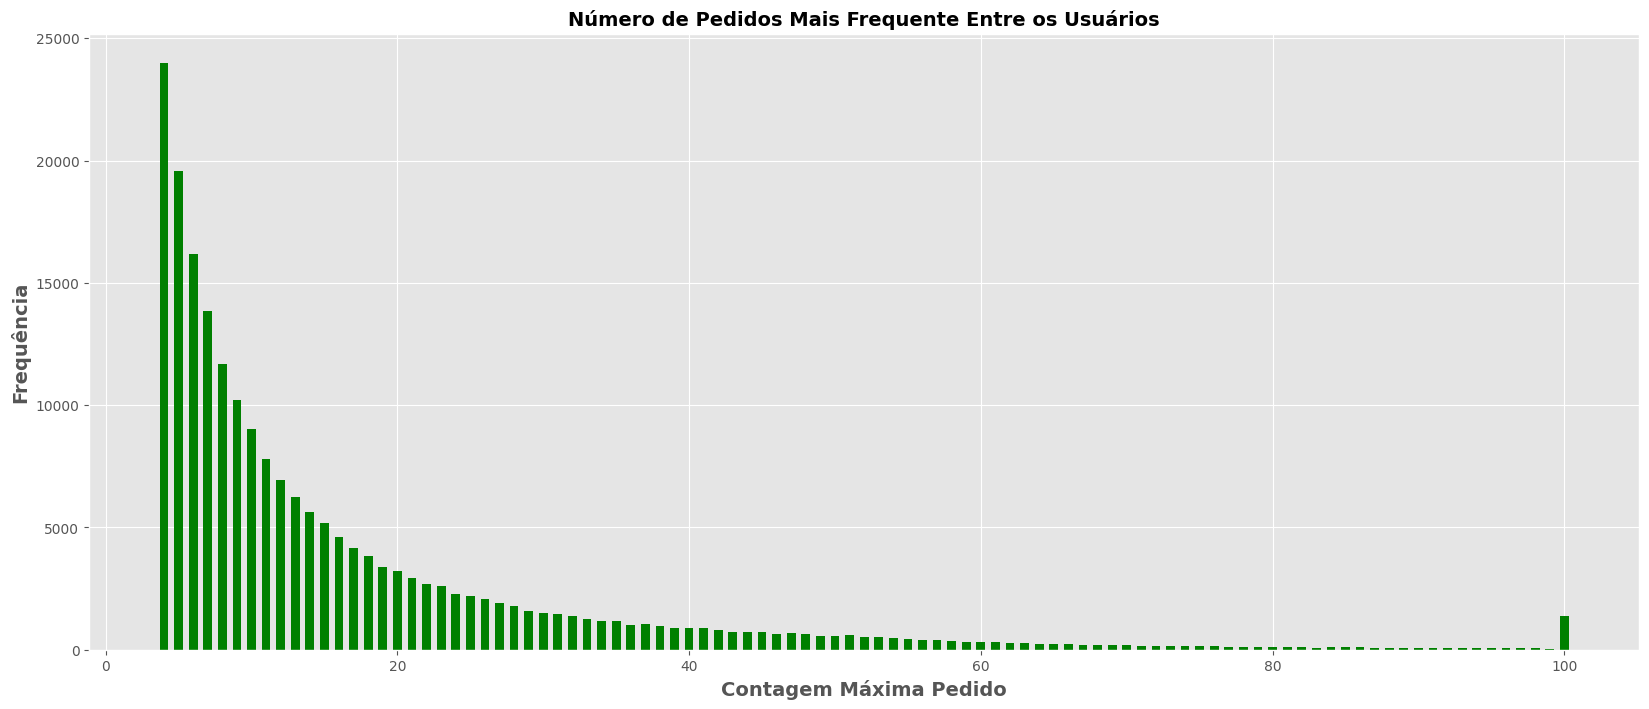

In [38]:
plt.style.use('ggplot')
plt.figure(figsize=(20, 8))

plt.bar(contagem_maxima_pedidos.index,
        contagem_maxima_pedidos.values,
        color='green',
        width=0.6)

plt.xlabel('Contagem Máxima Pedido', fontsize=14, fontweight='bold')
plt.ylabel('Frequência', fontsize=14, fontweight='bold')
plt.title('Número de Pedidos Mais Frequente Entre os Usuários', fontsize=14, fontweight='bold')

plt.show()

**2 - Qual dia da semana tem o maior numerio de pedidos?**

In [39]:
dias = {
    0: 'Domingo',
    1: 'Segunda',
    2: 'Terça',
    3: 'Quarta',
    4: 'Quinta',
    5: 'Sexta',
    6: 'Sábado'
}

contagem = dados_pedidos['order_dow'].value_counts()

dia_numero = contagem.idxmax()
qtd_pedidos = contagem.max()

print('Dia com mais pedidos:', dias[dia_numero])
print('Quantidade de pedidos:', qtd_pedidos)




Dia com mais pedidos: Domingo
Quantidade de pedidos: 600905


In [40]:
dados_pedidos.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [41]:
dados_pedidos.order_dow.value_counts()

,count
order_dow,
0,600905
1,587478
2,467260
5,453368
6,448761
3,436972
4,426339


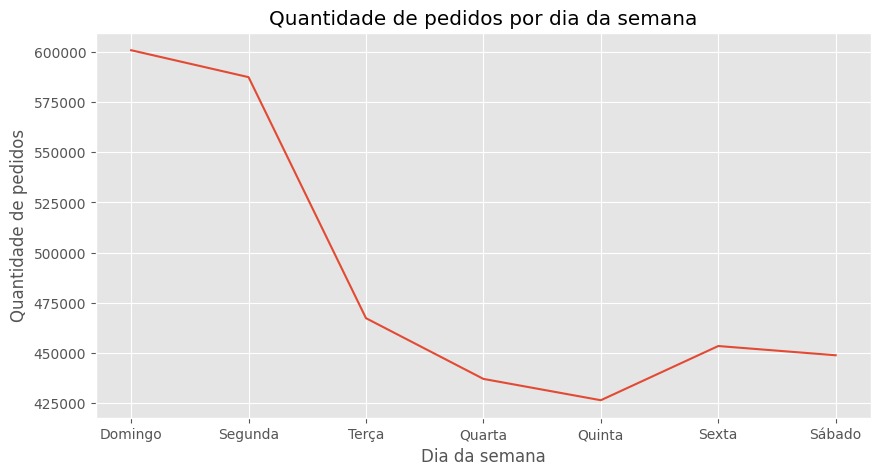

In [42]:
import matplotlib.pyplot as plt

# Create the tabela_dia_semana DataFrame
tabela_dia_semana = contagem.sort_index().reset_index()
tabela_dia_semana.columns = ['dia_semana', 'qtd_pedidos']

# Map numerical days to names for better readability on the plot
tabela_dia_semana['dia_semana'] = tabela_dia_semana['dia_semana'].map(dias)

plt.figure(figsize=(10, 5))
plt.plot(tabela_dia_semana['dia_semana'],
         tabela_dia_semana['qtd_pedidos'])
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade de pedidos')
plt.title('Quantidade de pedidos por dia da semana')
plt.grid(True)
plt.show()

**3 - Qual hora do dia tem o maior numero de pedidos?**

In [43]:
tabela_top5_horas = dados_pedidos['order_hour_of_day'].value_counts().head(5).reset_index()
tabela_top5_horas.columns = ['hora_do_dia', 'qtd_pedidos']

tabela_top5_horas


,hora_do_dia,qtd_pedidos
0,10,288418
1,11,284728
2,15,283639
3,14,283042
4,13,277999


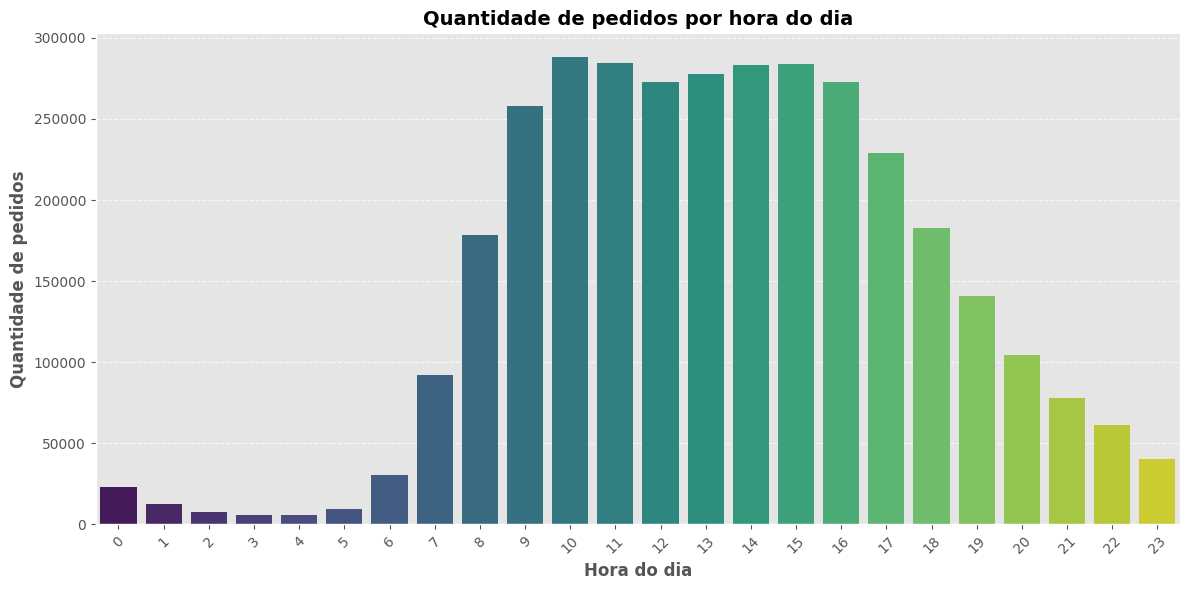

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

tabela_horas = dados_pedidos['order_hour_of_day'].value_counts().sort_index().reset_index()
tabela_horas.columns = ['hora_do_dia', 'qtd_pedidos']

plt.figure(figsize=(12, 6))
sns.barplot(x='hora_do_dia', y='qtd_pedidos', data=tabela_horas, palette='viridis')
plt.xlabel('Hora do dia', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de pedidos', fontsize=12, fontweight='bold')
plt.title('Quantidade de pedidos por hora do dia', fontsize=14, fontweight='bold')
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [45]:
dados_pedidos['order_hour_of_day'].value_counts().head(1)

,count
order_hour_of_day,
10,288418


**4 - Qual o departamento tem o maior numero de pedidos?**

In [46]:
tabela_top5_departamentos = dados_transacoes['department'].value_counts().head(5).reset_index()
tabela_top5_departamentos.columns = ['departamento', 'qtd_pedidos']

tabela_top5_departamentos


,departamento,qtd_pedidos
0,produce,145463
1,dairy eggs,83779
2,snacks,44513
3,beverages,41613
4,frozen,34773


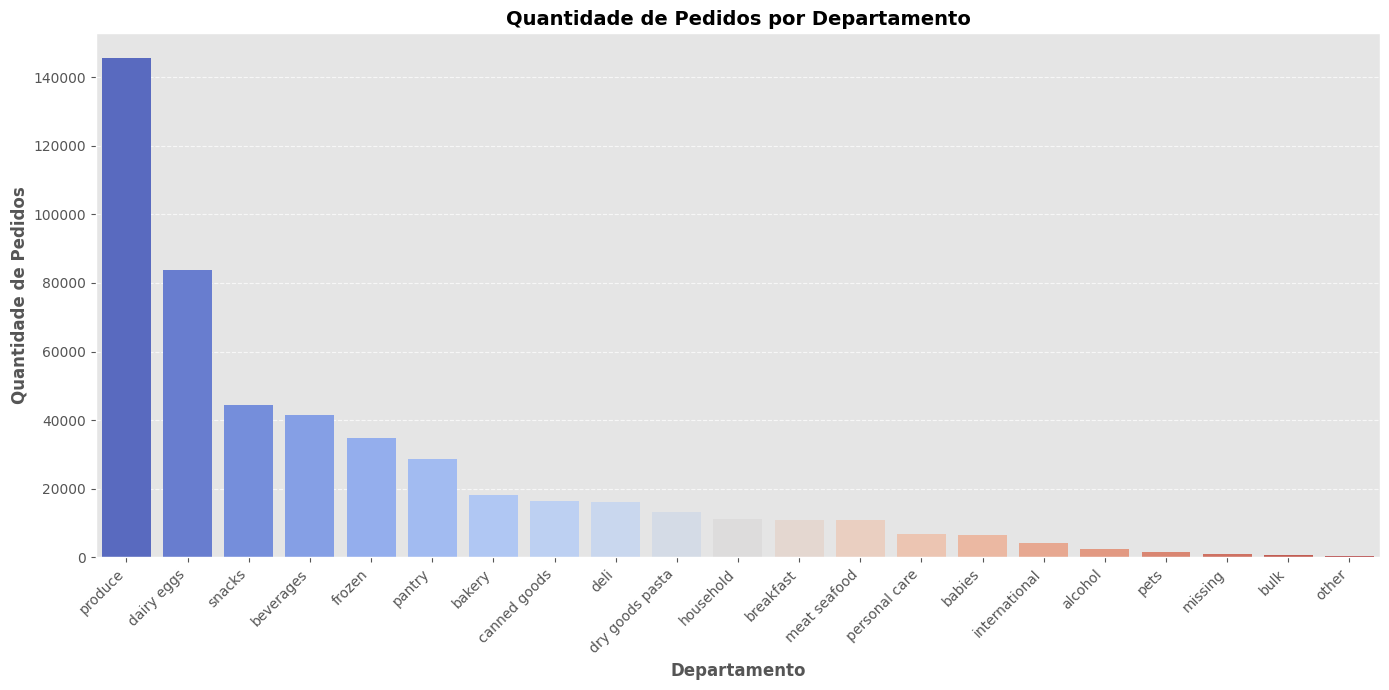

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

tabela_departamentos = dados_transacoes['department'].value_counts().reset_index()
tabela_departamentos.columns = ['departamento', 'qtd_pedidos']

plt.figure(figsize=(14, 7))
sns.barplot(x='departamento', y='qtd_pedidos', data=tabela_departamentos, palette='coolwarm')
plt.xlabel('Departamento', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Pedidos', fontsize=12, fontweight='bold')
plt.title('Quantidade de Pedidos por Departamento', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotate and align labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [48]:
dados_transacoes['department'].value_counts().head(1)


,count
department,
produce,145463


**5 - Quais os 20 principais corredores por frequecia de padidos?**

In [49]:
tabela_top20_corredores = dados_transacoes['aisle'].value_counts().head(20).reset_index()
tabela_top20_corredores.columns = ['corredor', 'qtd_pedidos']

tabela_top20_corredores


,corredor,qtd_pedidos
0,fresh fruits,56326
1,fresh vegetables,52073
2,packaged vegetables fruits,27347
3,yogurt,22485
4,packaged cheese,14960
5,milk,13715
6,water seltzer sparkling water,12778
7,chips pretzels,10982
8,soy lactosefree,10056
9,bread,9240


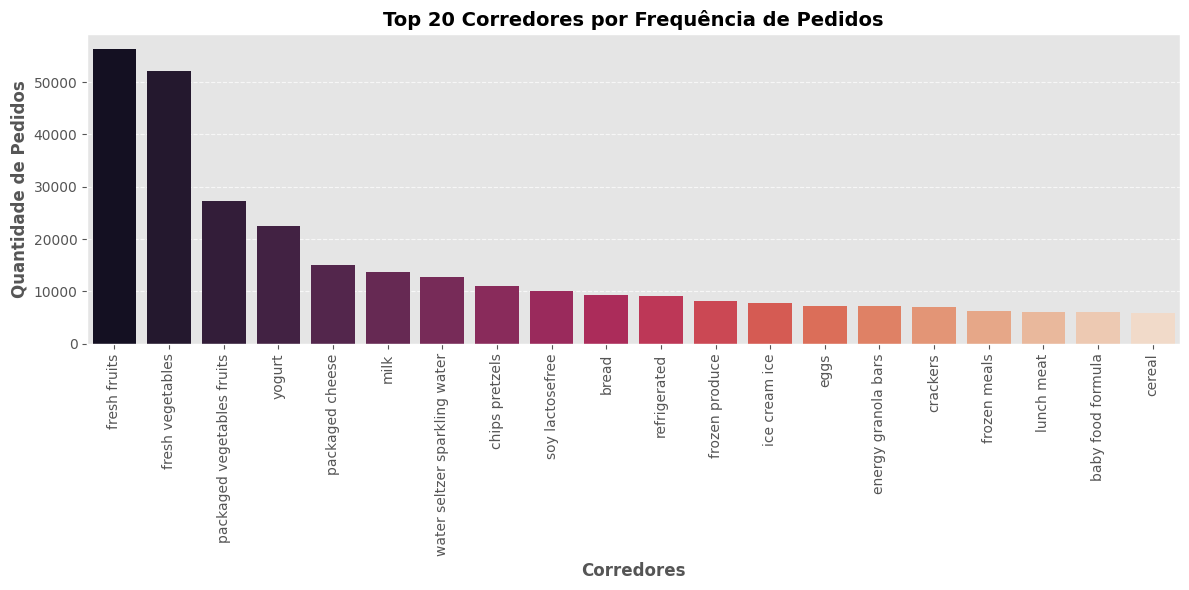

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='corredor', y='qtd_pedidos', data=tabela_top20_corredores, palette='rocket')
plt.xlabel('Corredores', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Pedidos', fontsize=12, fontweight='bold')
plt.title('Top 20 Corredores por Frequência de Pedidos', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='center') # Rotate and align labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [51]:
dados_transacoes['aisle'].value_counts().head(20)


,count
aisle,
fresh fruits,56326
fresh vegetables,52073
packaged vegetables fruits,27347
yogurt,22485
packaged cheese,14960
milk,13715
water seltzer sparkling water,12778
chips pretzels,10982
soy lactosefree,10056


**6 - Quais os 10 pricipais produtos por frequacia de pedidos?**

In [52]:
tabela_top10_produtos = dados_transacoes['product_name'].value_counts().head(10).reset_index()
tabela_top10_produtos.columns = ['produto', 'qtd_pedidos']

tabela_top10_produtos


,produto,qtd_pedidos
0,Banana,7365
1,Bag of Organic Bananas,5920
2,Organic Strawberries,4023
3,Organic Baby Spinach,3797
4,Organic Hass Avocado,3317
5,Organic Avocado,2712
6,Large Lemon,2355
7,Strawberries,2225
8,Organic Raspberries,2177
9,Limes,2116


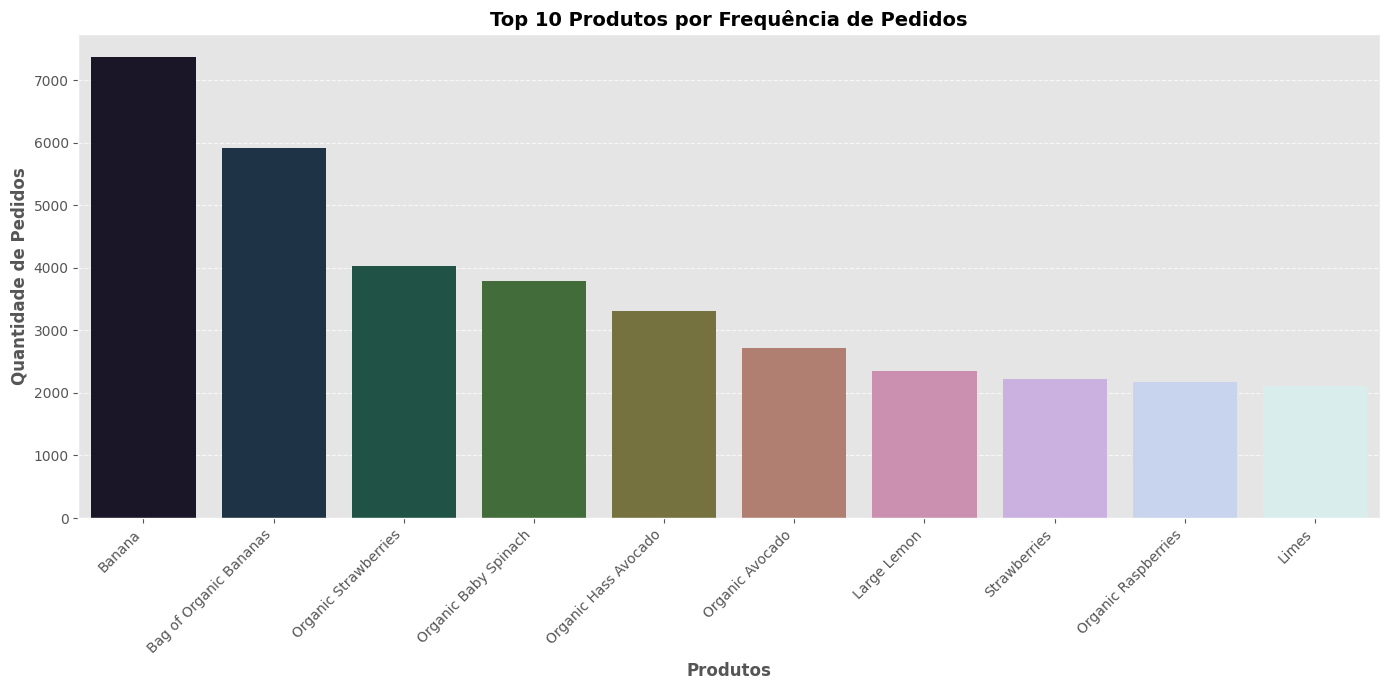

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7)) # Adjust figure size
sns.barplot(x='produto', y='qtd_pedidos', data=tabela_top10_produtos, palette='cubehelix') # Use seaborn barplot with a nice palette
plt.xlabel('Produtos', fontsize=12, fontweight='bold') # Enhance labels
plt.ylabel('Quantidade de Pedidos', fontsize=12, fontweight='bold') # Enhance labels
plt.title('Top 10 Produtos por Frequência de Pedidos', fontsize=14, fontweight='bold') # Enhance title
plt.xticks(rotation=45, ha='right') # Rotate and align x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid for easier comparison
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [54]:
dados_transacoes['product_name'].value_counts().head(10)


,count
product_name,
Banana,7365
Bag of Organic Bananas,5920
Organic Strawberries,4023
Organic Baby Spinach,3797
Organic Hass Avocado,3317
Organic Avocado,2712
Large Lemon,2355
Strawberries,2225
Organic Raspberries,2177


**7 - Faça a analise de novos pedidos semelhantes e pedidos anteriores (REORDER)**

reordered

0 = produto comprado pela primeira vez  
1 = produto que já foi comprado antes (recompra)


In [55]:
tabela_reorder = dados_transacoes['reordered'].value_counts().reset_index()
tabela_reorder.columns = ['tipo_pedido', 'qtd_pedidos']

# Converter 0 e 1 para texto
tabela_reorder['tipo_pedido'] = tabela_reorder['tipo_pedido'].map({
    0: 'Novo pedido',
    1: 'Pedido recorrente'
})

tabela_reorder


,tipo_pedido,qtd_pedidos
0,Pedido recorrente,295123
1,Novo pedido,204877


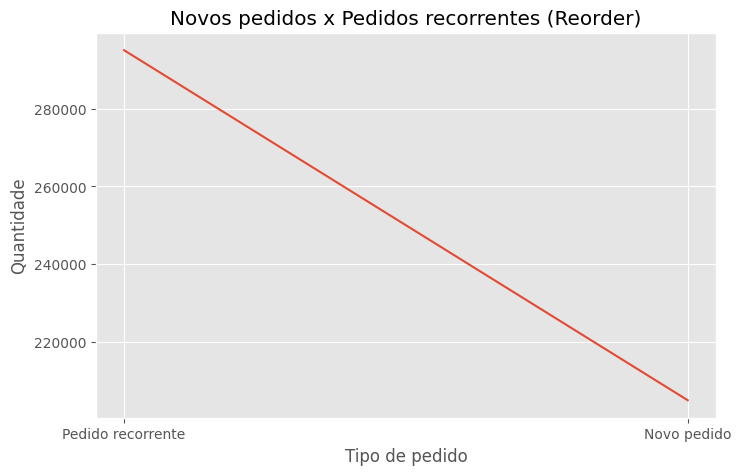

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(tabela_reorder['tipo_pedido'],
         tabela_reorder['qtd_pedidos'])
plt.xlabel('Tipo de pedido')
plt.ylabel('Quantidade')
plt.title('Novos pedidos x Pedidos recorrentes (Reorder)')
plt.grid(True)
plt.show()


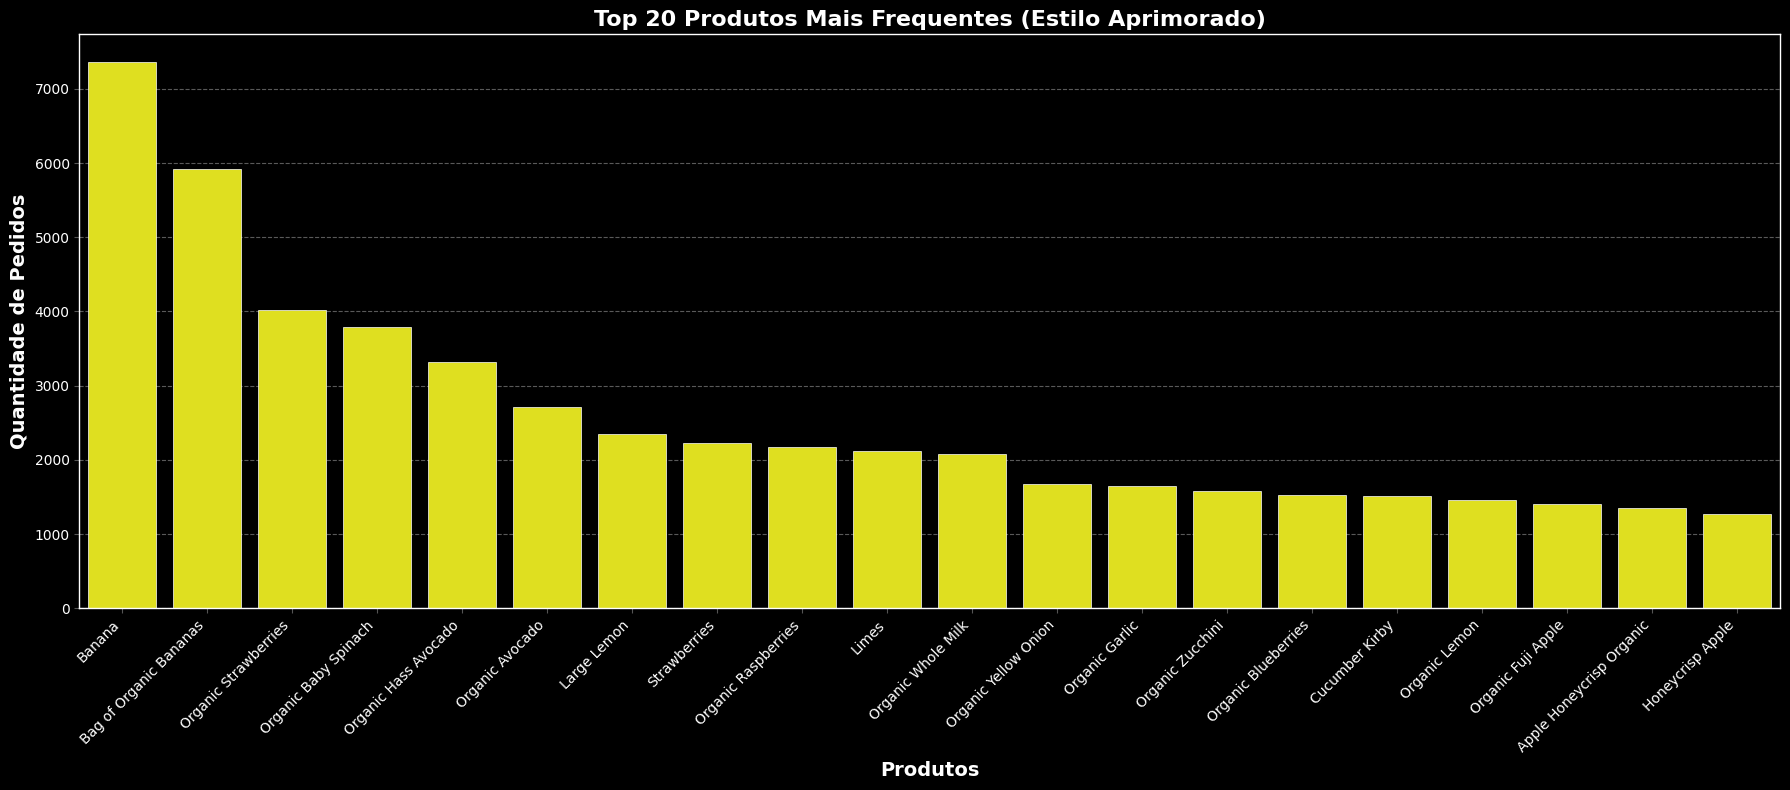

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
sns.barplot(x='produto', y='qtd_pedidos', data=tabela_top20_produtos, palette=['yellow'], edgecolor='white') # Use yellow bars with white edges
plt.xlabel('Produtos', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Quantidade de Pedidos', fontsize=14, fontweight='bold', color='white')
plt.title('Top 20 Produtos Mais Frequentes (Estilo Aprimorado)', fontsize=16, fontweight='bold', color='white')
plt.xticks(rotation=45, ha='right', fontsize=10, color='white')
plt.yticks(fontsize=10, color='white')
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()

In [57]:
dados_transacoes['reordered'].value_counts()


,count
reordered,
1,295123
0,204877


**8 - faça a analise de reorder por deparatamento ao longo do tempo**

In [58]:
tabela_reorder_tempo = dados_transacoes.groupby(
    ['department', 'order_number']
)['reordered'].sum().reset_index()

tabela_reorder_tempo


,department,order_number,reordered
0,alcohol,1,0
1,alcohol,2,55
2,alcohol,3,79
3,alcohol,4,70
4,alcohol,5,65
...,...,...,...
1968,snacks,95,6
1969,snacks,96,19
1970,snacks,97,12
1971,snacks,98,10


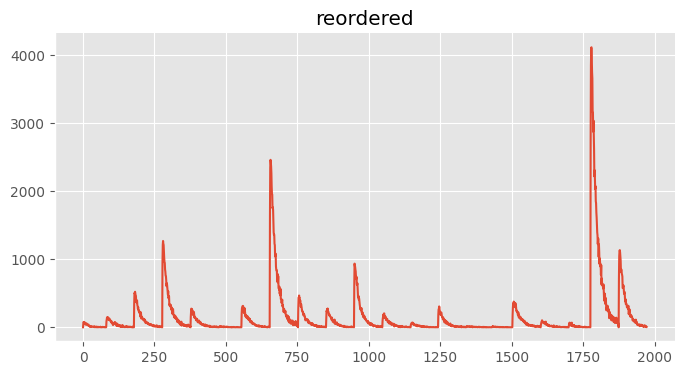

In [59]:
from matplotlib import pyplot as plt
tabela_reorder_tempo['reordered'].plot(kind='line', figsize=(8, 4), title='reordered')
plt.gca().spines[['top', 'right']].set_visible(False)

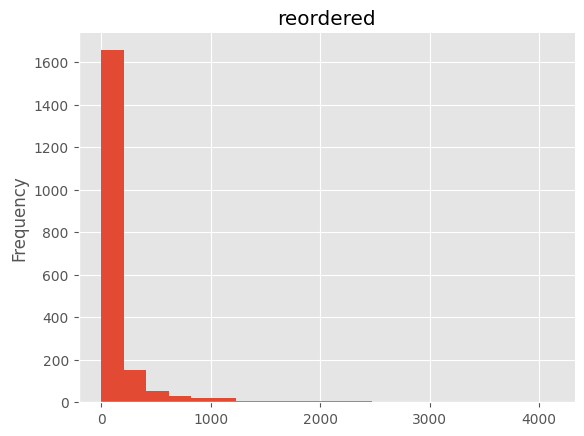

In [60]:
from matplotlib import pyplot as plt
tabela_reorder_tempo['reordered'].plot(kind='hist', bins=20, title='reordered')
plt.gca().spines[['top', 'right',]].set_visible(False)

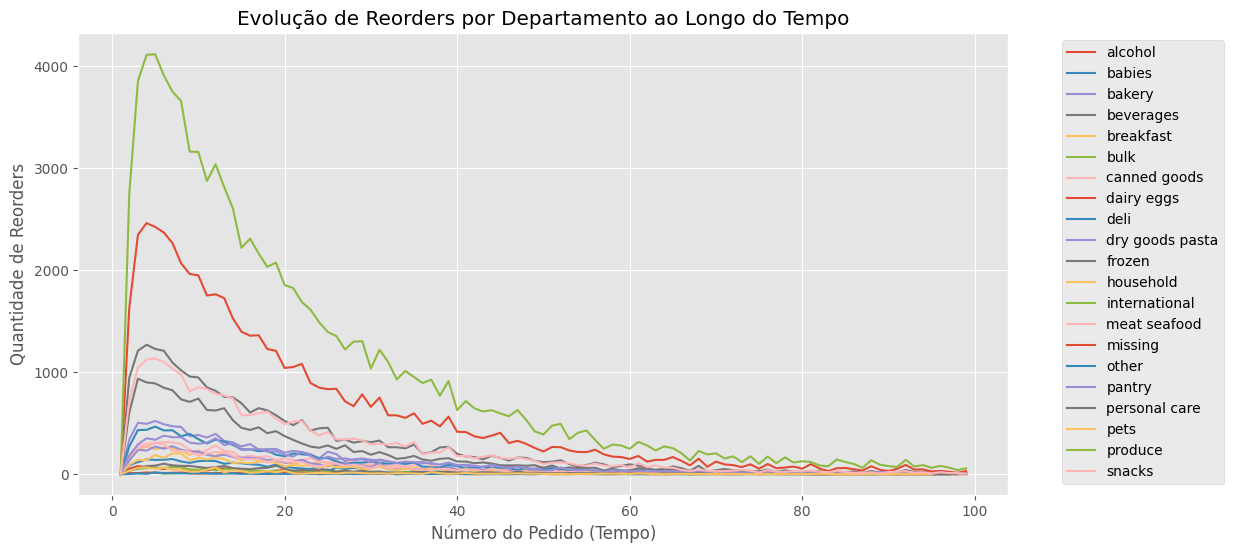

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for dept in tabela_reorder_tempo['department'].unique():
    dados_dept = tabela_reorder_tempo[tabela_reorder_tempo['department'] == dept]
    plt.plot(dados_dept['order_number'], dados_dept['reordered'], label=dept)

plt.xlabel('Número do Pedido (Tempo)')
plt.ylabel('Quantidade de Reorders')
plt.title('Evolução de Reorders por Departamento ao Longo do Tempo')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [62]:
dados_transacoes[dados_transacoes['reordered'] == 1]['department'].value_counts().head(10)


,count
department,
produce,94780
dairy eggs,56194
beverages,27053
snacks,25540
frozen,18683
bakery,11610
pantry,9988
deli,9894
canned goods,7544


**9 - Faça a analise de reorder e pedidos**

In [63]:
tabela_reorder_pedidos = dados_transacoes.groupby(
    'order_number'
)['reordered'].sum().reset_index()

tabela_reorder_pedidos.columns = ['numero_pedido', 'qtd_reorders']

tabela_reorder_pedidos


,numero_pedido,qtd_reorders
0,1,0
1,2,8483
2,3,12170
3,4,12811
4,5,12895
...,...,...
94,95,163
95,96,211
96,97,169
97,98,109


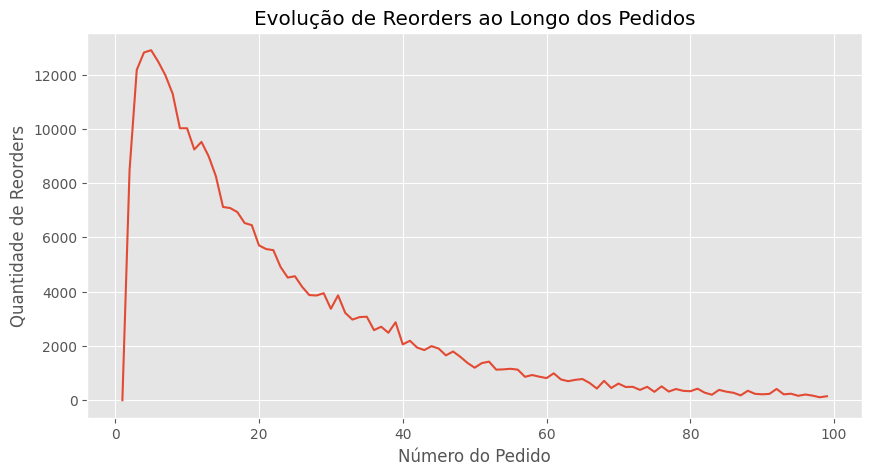

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(tabela_reorder_pedidos['numero_pedido'],
         tabela_reorder_pedidos['qtd_reorders'])
plt.xlabel('Número do Pedido')
plt.ylabel('Quantidade de Reorders')
plt.title('Evolução de Reorders ao Longo dos Pedidos')
plt.grid(True)
plt.show()


In [65]:
dados_transacoes['reordered'].value_counts()


,count
reordered,
1,295123
0,204877


**10 - faça a analise de reorder por corredor**

In [66]:
tabela_reorder_corredor = (
    dados_transacoes[dados_transacoes['reordered'] == 1]
    ['aisle']
    .value_counts()
    .head(10)
    .reset_index()
)

tabela_reorder_corredor.columns = ['corredor', 'qtd_reorders']

tabela_reorder_corredor


,corredor,qtd_reorders
0,fresh fruits,40531
1,fresh vegetables,31111
2,packaged vegetables fruits,17416
3,yogurt,15341
4,milk,10685
5,water seltzer sparkling water,9264
6,packaged cheese,8754
7,soy lactosefree,7059
8,chips pretzels,6535
9,bread,6290


### **Calculando a Taxa de Reorder por Corredor**

In [77]:
# Calcular o total de produtos vendidos por corredor
total_produtos_por_corredor = dados_transacoes['aisle'].value_counts().reset_index()
total_produtos_por_corredor.columns = ['corredor', 'total_pedidos']

# Obter o número de reorders por corredor (já calculado anteriormente como tabela_reorder_corredor_total)
reorders_por_corredor = tabela_reorder_corredor_total.copy()
reorders_por_corredor.columns = ['corredor', 'total_reorders']

# Unir os dois dataframes
analise_reorder_corredor = pd.merge(
    total_produtos_por_corredor,
    reorders_por_corredor,
    on='corredor',
    how='left'
)

# Calcular a taxa de reorder
analise_reorder_corredor['taxa_reorder'] = (
    analise_reorder_corredor['total_reorders'] / analise_reorder_corredor['total_pedidos']
) * 100

# Preencher NaN com 0 para corredores sem reorders
analise_reorder_corredor['taxa_reorder'] = analise_reorder_corredor['taxa_reorder'].fillna(0)

# Exibir os 10 corredores com a maior taxa de reorder
analise_reorder_corredor_top10 = analise_reorder_corredor.sort_values(by='taxa_reorder', ascending=False).head(10)
display(analise_reorder_corredor_top10)

,corredor,total_pedidos,total_reorders,taxa_reorder
5,milk,13715,10685,77.907401
6,water seltzer sparkling water,12778,9264,72.499609
0,fresh fruits,56326,40531,71.957888
13,eggs,7121,5084,71.394467
8,soy lactosefree,10056,7059,70.196897
33,packaged produce,4144,2881,69.522201
25,cream,4876,3385,69.421657
3,yogurt,22485,15341,68.227707
9,bread,9240,6290,68.073593
10,refrigerated,9023,6001,66.507813


### **Visualização da Taxa de Reorder por Corredor (Top 10)**

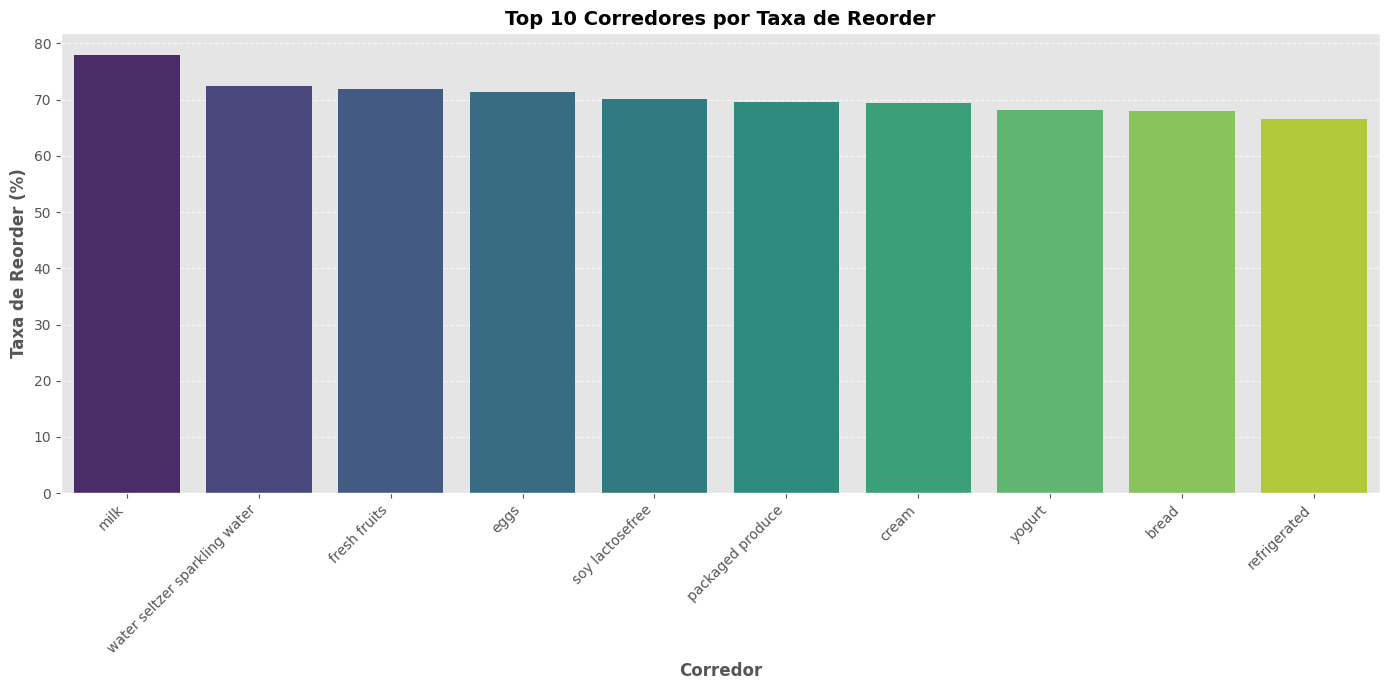

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(
    x='corredor',
    y='taxa_reorder',
    data=analise_reorder_corredor_top10,
    palette='viridis'
)
plt.xlabel('Corredor', fontsize=12, fontweight='bold')
plt.ylabel('Taxa de Reorder (%)', fontsize=12, fontweight='bold')
plt.title('Top 10 Corredores por Taxa de Reorder', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

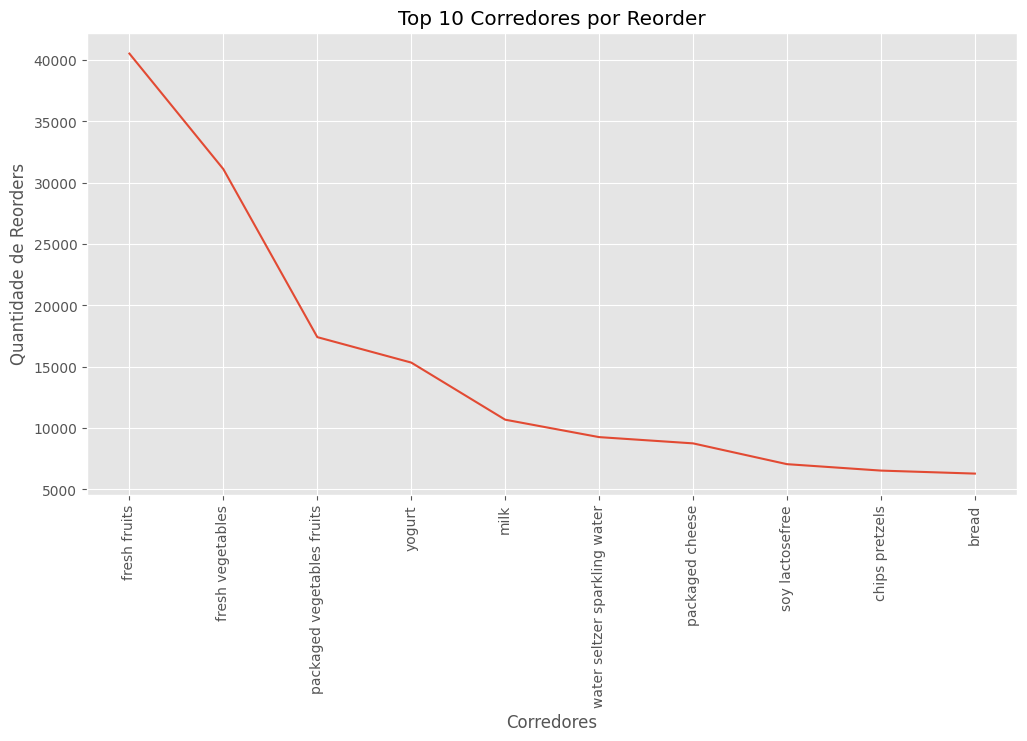

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(tabela_reorder_corredor['corredor'],
         tabela_reorder_corredor['qtd_reorders'])
plt.xlabel('Corredores')
plt.ylabel('Quantidade de Reorders')
plt.title('Top 10 Corredores por Reorder')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


**10.1 - faça a analise de reorder por corredor (TOTAL)**

In [68]:
tabela_reorder_corredor_total = (
    dados_transacoes[dados_transacoes['reordered'] == 1]
    ['aisle']
    .value_counts()
    .reset_index()
)

tabela_reorder_corredor_total.columns = ['corredor', 'qtd_reorders']

tabela_reorder_corredor_total


,corredor,qtd_reorders
0,fresh fruits,40531
1,fresh vegetables,31111
2,packaged vegetables fruits,17416
3,yogurt,15341
4,milk,10685
...,...,...
129,frozen juice,30
130,first aid,27
131,kitchen supplies,25
132,eye ear care,21


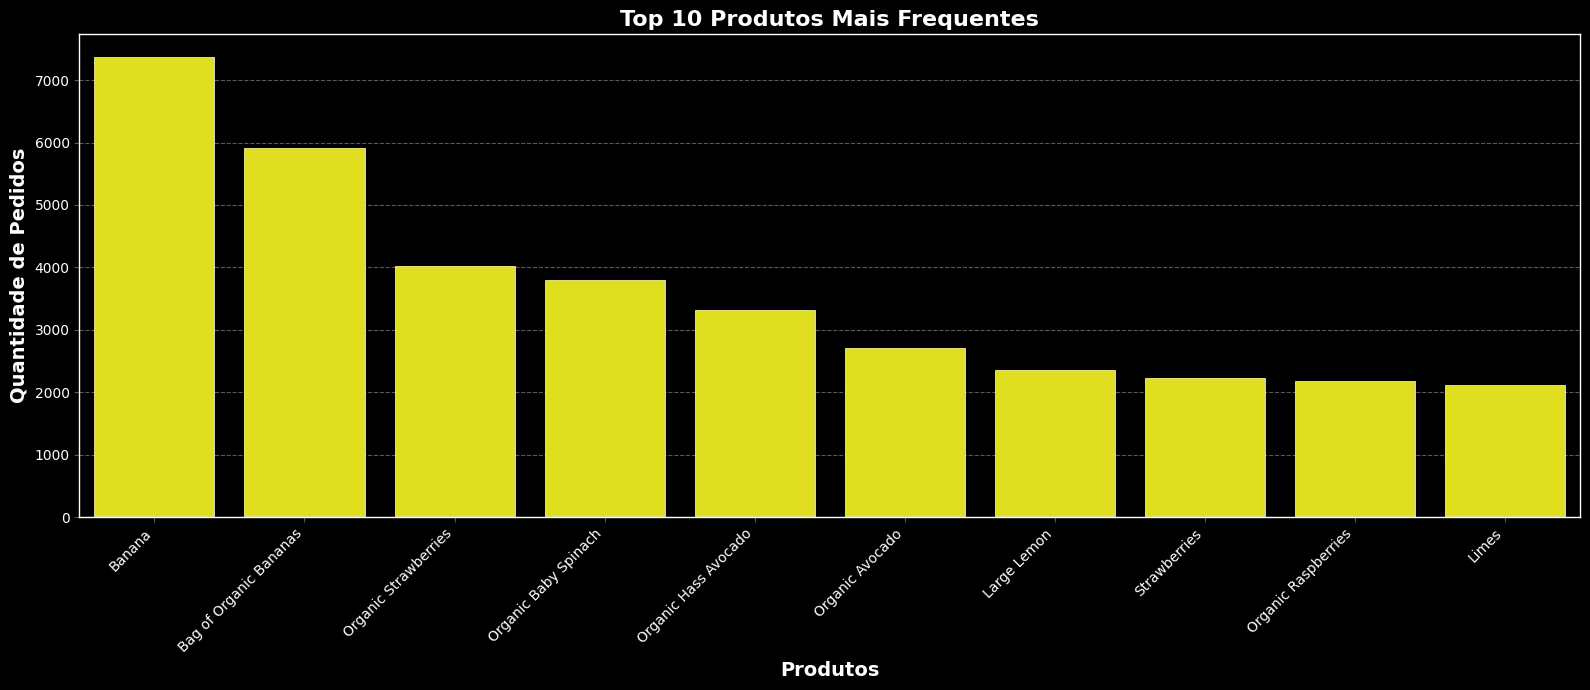

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 7), facecolor='black') # Adjust figure size and set background
ax = plt.gca()
ax.set_facecolor('black')
sns.barplot(x='produto', y='qtd_pedidos', data=tabela_top10_produtos, palette=['yellow'], edgecolor='white')
plt.xlabel('Produtos', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Quantidade de Pedidos', fontsize=14, fontweight='bold', color='white')
plt.title('Top 10 Produtos Mais Frequentes', fontsize=16, fontweight='bold', color='white')
plt.xticks(rotation=45, ha='right', fontsize=10, color='white')
plt.yticks(fontsize=10, color='white')
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.tight_layout()
plt.show()